# 03 Feature Diagnostics

This notebook checks correlations among the final numeric and binary predictors created in the preprocessing notebook. The diagnostic corresponds to the feature diagnostics reported in the thesis.

## 1. Imports and paths

This section imports the required libraries and defines repository-style input and output paths.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", "{:.2f}".format)

# Expected project structure:
# thesis-startup-success-prediction/
# ├── data/processed/startup_preprocessed_unsplit.csv
# ├── notebooks/03_feature_diagnostics.ipynb
# └── outputs/

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PREPROCESSED_DATA_PATH = PROJECT_DIR / "data" / "processed" / "startup_preprocessed_unsplit.csv"
FEATURE_DIAGNOSTIC_TABLE_DIR = PROJECT_DIR / "outputs" / "tables" / "feature_diagnostics"
FEATURE_DIAGNOSTIC_FIGURE_DIR = PROJECT_DIR / "outputs" / "figures" / "feature_diagnostics"

FEATURE_DIAGNOSTIC_TABLE_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_DIAGNOSTIC_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

CORRELATION_MATRIX_PATH = FEATURE_DIAGNOSTIC_TABLE_DIR / "feature_correlation_matrix.csv"
HIGH_CORRELATION_PAIRS_PATH = FEATURE_DIAGNOSTIC_TABLE_DIR / "high_correlation_pairs.csv"
NOTABLE_CORRELATION_PAIRS_PATH = FEATURE_DIAGNOSTIC_TABLE_DIR / "notable_correlation_pairs.csv"
CORRELATION_FIGURE_PATH = FEATURE_DIAGNOSTIC_FIGURE_DIR / "feature_correlation_matrix.png"

if not PREPROCESSED_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Preprocessed dataset not found: {PREPROCESSED_DATA_PATH}. "
        "Run 02_preprocessing_feature_engineering.ipynb first."
    )

print("Setup completed.")

Setup completed.


## 2. Load the preprocessed dataset

This section loads the unsplit modeling dataset produced by the preprocessing and feature-engineering notebook.

In [2]:
df_model = pd.read_csv(PREPROCESSED_DATA_PATH)

print("Preprocessed unsplit dataset shape:", df_model.shape)
display(df_model.head())

Preprocessed unsplit dataset shape: (5704, 22)


,funding_total_usd,seed,venture,angel,debt_financing,private_equity,undisclosed,founded_year,funding_rounds,funding_duration_days,avg_days_between_rounds,is_single_round,has_round_a,has_round_b,has_round_c,has_round_d,has_round_e,country_code,market,target,is_usa,last_funding_at
0,14.38,14.38,0.00,0.00,0.00,0.00,0.00,2012.00,1.00,0,0.00,1,0,0,0,0,0,USA,News,1,1,2012-06-30
1,15.41,0.00,0.00,0.00,0.00,0.00,15.41,2007.00,1.00,0,0.00,1,0,0,0,0,0,ARG,Advertising,0,0,2007-01-16
2,13.12,13.12,0.00,0.00,0.00,0.00,0.00,2009.00,1.00,0,0.00,1,0,0,0,0,0,other,Marketplaces,1,0,2009-05-15
3,14.04,13.53,13.12,0.00,0.00,0.00,0.00,2011.00,2.00,28,28.00,0,0,0,0,0,0,USA,Analytics,1,1,2011-11-30
4,10.82,10.82,0.00,0.00,0.00,0.00,0.00,2009.00,1.00,0,0.00,1,0,0,0,0,0,USA,Curated Web,0,1,2009-04-01


## 3. Define correlation diagnostic features

This section defines the final numeric and binary predictors included in the feature correlation diagnostic.

In [3]:
TARGET_COLUMN = "target"
SUBGROUP_COLUMN = "is_usa"
TEMPORAL_SPLIT_COLUMN = "last_funding_at"

funding_scale_features = [
    "funding_total_usd", "seed", "venture", "angel",
    "debt_financing", "private_equity", "undisclosed",
]

funding_dynamics_features = [
    "founded_year", "funding_rounds",
    "funding_duration_days", "avg_days_between_rounds", "is_single_round",
]

stage_structure_features = [
    "has_round_a", "has_round_b", "has_round_c", "has_round_d", "has_round_e",
]

correlation_features = (
    funding_scale_features
    + funding_dynamics_features
    + stage_structure_features
)

excluded_from_correlation = [
    TARGET_COLUMN,
    SUBGROUP_COLUMN,
    TEMPORAL_SPLIT_COLUMN,
    "country_code",
    "market",
]

missing_correlation_features = [col for col in correlation_features if col not in df_model.columns]
if missing_correlation_features:
    raise KeyError(f"Missing expected correlation features: {missing_correlation_features}")

correlation_feature_table = pd.DataFrame(
    {
        "included_correlation_feature": correlation_features
    }
)

excluded_feature_table = pd.DataFrame(
    {
        "excluded_variable": excluded_from_correlation,
        "reason": [
            "target variable",
            "subgroup-only variable",
            "temporal split variable",
            "categorical predictor",
            "categorical predictor",
        ],
    }
)

display(correlation_feature_table)
display(excluded_feature_table)

,included_correlation_feature
0,funding_total_usd
1,seed
2,venture
3,angel
4,debt_financing
5,private_equity
6,undisclosed
7,founded_year
8,funding_rounds
9,funding_duration_days


,excluded_variable,reason
0,target,target variable
1,is_usa,subgroup-only variable
2,last_funding_at,temporal split variable
3,country_code,categorical predictor
4,market,categorical predictor


## 4. Compute the correlation matrix

This section computes Pearson correlations among the final numeric and binary predictors.

In [4]:
corr_matrix = df_model[correlation_features].corr(method="pearson")
corr_matrix_display = corr_matrix.round(2)

display(corr_matrix_display)

,funding_total_usd,seed,venture,angel,debt_financing,private_equity,undisclosed,founded_year,funding_rounds,funding_duration_days,avg_days_between_rounds,is_single_round,has_round_a,has_round_b,has_round_c,has_round_d,has_round_e
funding_total_usd,1.00,0.03,0.68,0.05,0.18,0.13,0.05,-0.23,0.36,0.36,0.31,-0.40,0.33,0.34,0.27,0.19,0.11
seed,0.03,1.00,-0.41,-0.03,-0.10,-0.05,-0.04,0.33,-0.03,-0.09,-0.07,-0.00,-0.13,-0.18,-0.14,-0.10,-0.07
venture,0.68,-0.41,1.00,-0.19,0.08,-0.03,-0.08,-0.35,0.39,0.41,0.35,-0.42,0.49,0.45,0.34,0.23,0.14
angel,0.05,-0.03,-0.19,1.00,-0.04,-0.03,-0.03,0.07,0.04,-0.01,-0.01,-0.06,-0.04,-0.07,-0.06,-0.04,-0.03
debt_financing,0.18,-0.10,0.08,-0.04,1.00,0.04,-0.01,-0.07,0.40,0.30,0.15,-0.27,-0.00,0.07,0.08,0.11,0.11
private_equity,0.13,-0.05,-0.03,-0.03,0.04,1.00,0.00,-0.05,0.11,0.09,0.03,-0.06,-0.04,0.00,0.00,0.04,0.02
undisclosed,0.05,-0.04,-0.08,-0.03,-0.01,0.00,1.00,-0.10,0.06,0.03,0.03,-0.05,-0.04,-0.03,-0.03,-0.02,-0.01
founded_year,-0.23,0.33,-0.35,0.07,-0.07,-0.05,-0.10,1.00,-0.16,-0.26,-0.24,0.14,-0.04,-0.19,-0.22,-0.19,-0.14
funding_rounds,0.36,-0.03,0.39,0.04,0.40,0.11,0.06,-0.16,1.00,0.81,0.44,-0.74,0.32,0.46,0.45,0.35,0.22
funding_duration_days,0.36,-0.09,0.41,-0.01,0.30,0.09,0.03,-0.26,0.81,1.00,0.79,-0.70,0.29,0.46,0.46,0.35,0.20


## 5. Visualize the correlation matrix


This section creates the correlation matrix figure used in the thesis.

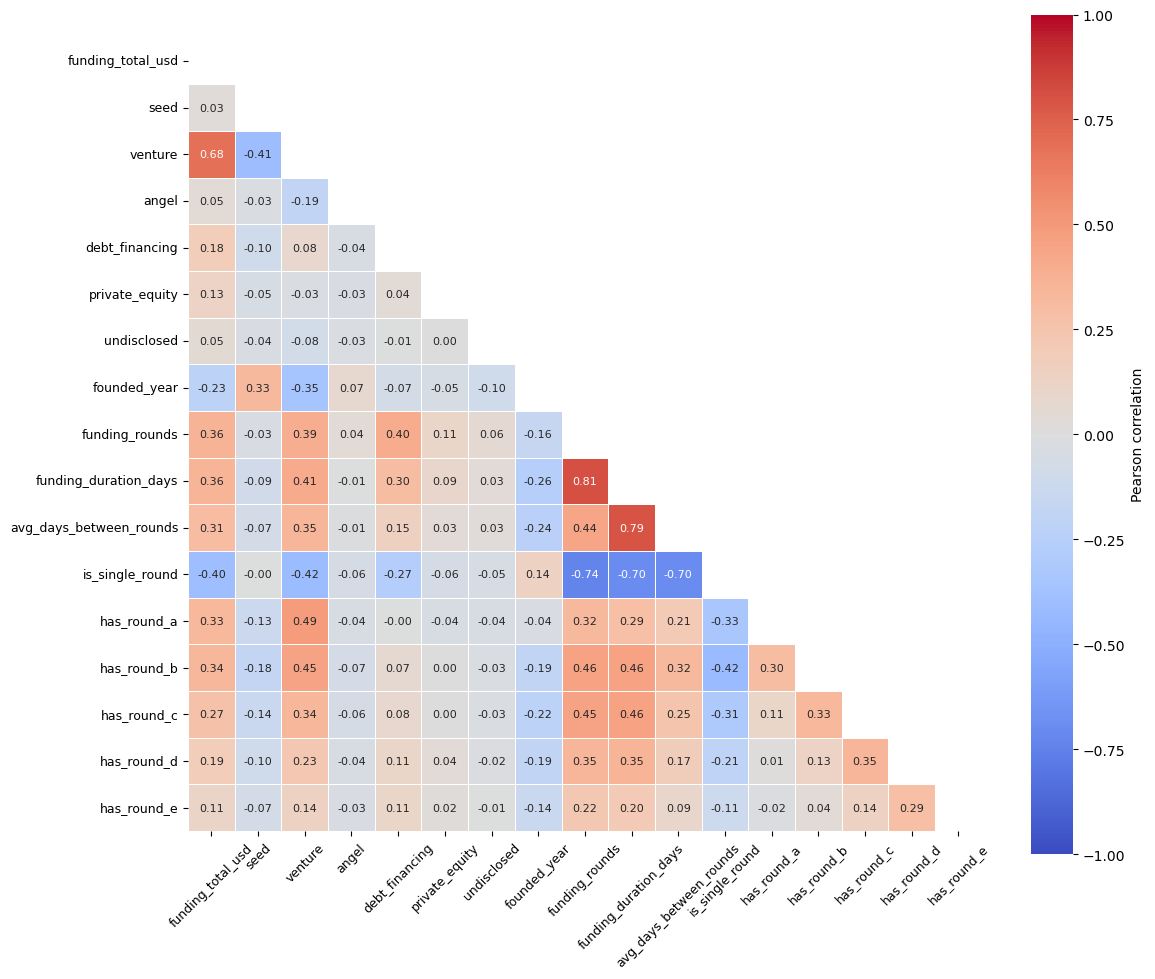

In [6]:
correlation_figure, ax = plt.subplots(figsize=(12, 10))

# Mask the upper triangle, including the diagonal
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson correlation"},
    annot_kws={"size": 8},
    ax=ax,
)

ax.set_title("")
ax.tick_params(axis="x", labelrotation=45, labelsize=9)
ax.tick_params(axis="y", labelrotation=0, labelsize=9)

plt.tight_layout()
plt.show()

## 7. Save outputs

This section saves the feature diagnostic tables and correlation matrix figure for later reporting.

In [7]:
corr_matrix_display.to_csv(CORRELATION_MATRIX_PATH)
high_correlation_pairs_display.to_csv(HIGH_CORRELATION_PAIRS_PATH, index=False)
notable_correlation_pairs_display.to_csv(NOTABLE_CORRELATION_PAIRS_PATH, index=False)

correlation_figure.savefig(
    CORRELATION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)